In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Financial Analysis with PyMC

A Bayesian study of equity volatility, benchmarked against an OLS baseline.
The notebook walks through three Bayesian models of increasing structure
- a sector-grouped volatility model, a Student-t time regression, and a
hierarchical (centered then non-centered) model with stock-level intercepts
and slopes drawn from group-level priors.

## Table of Contents
1. [Setup & Data](#setup--data)
2. [Frequentist Baseline](#frequentist-baseline)
3. [Bayesian Model — Sector-Grouped Volatility](#bayesian-model--sector-grouped-volatility)
4. [Bayesian Regression in Time](#bayesian-regression-in-time)
5. [Hierarchical Bayesian Model](#hierarchical-bayesian-model)
6. [Posterior Predictive: Price Simulation](#posterior-predictive-price-simulation)


In [ ]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import arviz as az
import statsmodels.api as sm

from utils import (
    load_prices_and_returns,
    describe_volatility_and_correlations,
    fit_ols_with_ci,
    plot_regression_with_intervals,
    compute_predicted_volatility,
    simulate_price_paths,
    plot_simulated_paths,
)


## Setup & Data

### Data Selection Strategy: Sector Diversification

We have intentionally selected a portfolio of stocks spanning distinct industry sectors (Technology, Industrials, and Consumer Staples).

**The Hypothesis:**
Our core assumption is that **volatility is not uniform across the market**. Instead, we hypothesize that risk (volatility) is a structural characteristic inherent to specific sectors. For example, we expect "defensive" sectors like Consumer Staples to exhibit different variance patterns compared to "growth" sectors like Technology.

**Upcoming Modeling Approach:**
To rigorously test this, our Bayesian analysis will not treat all assets identically. In the following sections, we will construct models where **different sectors are assigned unique priors for their return volatility**. This allows the model to learn sector-specific risk profiles ($\sigma_{sector}$) rather than forcing a single global volatility parameter on the entire dataset.

In [ ]:
print(f"Running on PyMC v{pm.__version__}")

# Ticker -> sector mapping
sektor_mapping = {
    'GOOG': 'TECHNOLOGY',
    'META': 'TECHNOLOGY',
    'CAT':  'PRODUCERS',
    'PEP':  'CONSUMER',
    'KO':   'CONSUMER',
}

TICKERS = list(sektor_mapping.keys())
sektors = sorted(set(sektor_mapping.values()))
sektor_names = ['TECHNOLOGY', 'CONSUMER', 'PRODUCERS']

N_STOCKS = len(TICKERS)
N_SECTORS = len(sektors)

sektor_lookup = {sektor: i for i, sektor in enumerate(sektors)}
sektor_idx = np.array([sektor_lookup[sektor_mapping[t]] for t in TICKERS])

START_DATE = '2024-01-01'
END_DATE   = '2025-07-09'

prices, returns, log_returns, scaled_returns, y_data = load_prices_and_returns(
    TICKERS, START_DATE, END_DATE,
)
num_days = y_data.shape[0]
print(f"Data dimensions: {y_data.shape[0]} trading days, {y_data.shape[1]} stocks.")


In [221]:
# (NaNs)
print(f"Are there any NaN values? {np.isnan(y_data).any()}")


Are there any NaN values? False


## Frequentist Baseline

**Establishing a Baseline: The Frequentist Approach**

Before constructing our Bayesian models, we first perform a traditional "Frequentist" analysis. The goal here is to establish a **benchmark** using standard statistical methods, specifically **Ordinary Least Squares (OLS) Regression**.

**Why do this?**
1.  **Sanity Check:** It ensures our data behaves as expected before adding the complexity of probabilistic programming.
2.  **Comparison Point:** It provides point estimates (single numbers for slope and intercept) that we can later compare against the *distributions* generated by our Bayesian models.
3.  **Assumption Testing:** It allows us to quickly visualize relationships and check for obvious violations of linear assumptions (like non-constant variance) that our hierarchical model will need to address.

In [ ]:
corr_matrix = describe_volatility_and_correlations(prices, log_returns)

**Interpreting the Correlation Matrix**

The correlation matrix above provides the first empirical evidence for our sector-based hypothesis. We observe distinct "blocks" of correlation that align with our industry classifications:

1.  **High Intra-Sector Correlation:**
    * Stocks within the **Technology** sector (GOOG, META) exhibit strong positive correlation.
    * Similarly, the **Consumer** staples (KO, PEP) show high correlation with each other.
    * *Logic:* This confirms that assets within the same sector share common risk factors and drivers (e.g., market sentiment, regulatory changes, or raw material costs).

2.  **Lower Inter-Sector Correlation:**
    * The correlation between different sectors (e.g., Technology vs. Consumer) is noticeably lower than the correlation within sectors.
    * *Logic:* This suggests that the drivers of volatility are structurally different across industries.

**Conclusion for Modeling:**
This structure confirms that treating all stocks as identical (pooling) would ignore valuable information. The data naturally clusters by sector, justifying our decision to build a **Hierarchical Bayesian Model** where we learn unique volatility parameters ($\sigma_{sector}$) for each group.

## CLASSICAL REGRESSION ON THE MEAN PRICE OF ALL STOCKS

In [ ]:
prices_clean = prices.dropna()
T = len(prices_clean)
time = np.arange(T)
avg_price = prices_clean.mean(axis=1).values

model_avg = fit_ols_with_ci(time, avg_price, label="Average Price")


The regression shows that ~57% of the variation in average price (y) is explained by time (x1), indicating a moderate fit (R² = 0.568). The slope is 0.1573 (p < 0.001), meaning the average price increases by ~0.157 units per time unit, and this effect is statistically significant.  

However, residual diagnostics reveal issues:  
- **Durbin-Watson = 0.058** → strong positive autocorrelation (likely time series effect)  
- **Jarque-Bera p < 0.0001** → residuals are not normally distributed  
- **Skew = -0.98**, **Kurtosis = 4.06** → asymmetric and fat-tailed residuals  

These violations suggest OLS assumptions are not fully met. A time series model (e.g., ARIMA) or robust standard errors (e.g., Newey-West) might be more appropriate.


## STOCK REGRESSION

In [ ]:
for ticker in TICKERS:
    series = prices_clean[ticker].values
    fit_ols_with_ci(
        time,
        series,
        label=ticker,
        line_color="red",
        fill_color="pink",
        figsize=(10, 4),
    )


## Bayesian Model — Sector-Grouped Volatility

**Defining Model Coordinates**

Before building the model, we establish a **coordinate system** (`coords`) to label our data dimensions.

**The Purpose:**
PyMC operates on multi-dimensional arrays. Without these coordinates, our model results would display generic indices (e.g., `sigma[0]`, `beta[1]`). By mapping these indices to meaningful labels now, our future plots and summaries will be automatically labeled with the correct **Ticker** and **Sector** names.

* **`stock`**: Maps the 5 columns to specific Tickers (e.g., GOOG, META).
* **`sector`**: Maps the group indices to Sector Names (e.g., TECHNOLOGY).
* **`obs_id`**: Tracks the specific time step for each observation.

In [225]:
coords = {
   "stock": TICKERS,
   "sector": sektor_names,
   "obs_id": np.arange(y_data.shape[0]) 
}


The model uses a Student’s T-distribution to account for fat tails in daily stock returns, making it more robust to outliers. The `nu` parameter controls tail heaviness and is assigned a Gamma prior (`Gamma(1, 1)`) to allow flexibility between normal-like and heavy-tailed behavior.

The prior on the mean return (`mu`) is `Normal(0, 1)`, reflecting the belief that daily returns are centered near 
zero with some allowance for variation.

Volatility is modeled hierarchically: each stock’s volatility (`sigma`) is drawn from a `HalfNormal` centered on its sector-level volatility (`sektor_sigma`). The sector-level volatility has a `HalfCauchy(beta=2)` prior, allowing for extreme values without constraining the model.

This structure encourages **shrinkage**: noisy or limited data for individual stocks are "pulled" toward the more stable sector-level estimates, improving generalization and preventing overfitting.


Likelihood Dim: 2


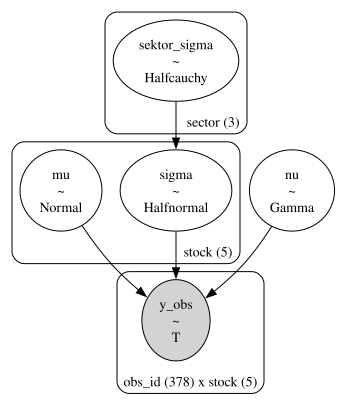

In [226]:
with pm.Model(coords=coords) as model_sektors:  #(coords=coords)


    # SEKTOR PRIORE FOR VOLATILITY
    sektor_sigma = pm.HalfCauchy("sektor_sigma", beta=2, dims="sector")
        
    # STOCK LEVEL PRIORS
    mu = pm.Normal("mu", mu=0, sigma=1, dims = "stock") 
        
    # THE OTHER PARAMETERS 
    sigma = pm.HalfNormal("sigma", sigma=sektor_sigma[sektor_idx], dims="stock")
    nu = pm.Gamma("nu", alpha=1, beta=1)

    # Likelihood
    y_sek_obs = pm.StudentT(
        "y_obs",
        nu=nu,
        mu=mu,
        
        sigma=sigma,
        observed=y_data,
        dims=("obs_id", "stock")
    )

# Visualization
    print(f"Likelihood Dim: {y_sek_obs.ndim}") 
    graph = pm.model_to_graphviz(model_sektors)
    display(graph)

In [227]:
with model_sektors:
    idata_sektors = pm.sample(
        1000,
        tune=1000,          
        chains=2,
        idata_kwargs={"log_likelihood": True},
        progressbar=False        
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sektor_sigma, mu, sigma, nu]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


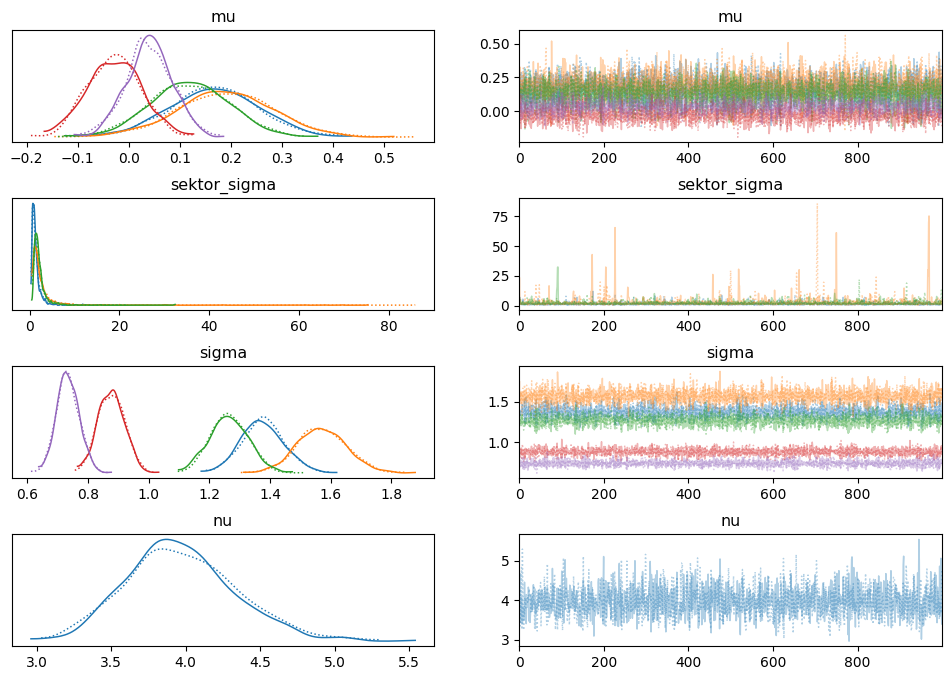

In [229]:
az.plot_trace(idata_sektors, figsize=(12, 8))
plt.subplots_adjust(hspace = 0.5)
plt.show()

In [230]:
az.summary(idata_sektors)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[GOOG],0.166,0.088,0.013,0.337,0.001,0.002,3715.0,1314.0,1.0
mu[META],0.189,0.095,0.004,0.368,0.001,0.002,4306.0,1612.0,1.0
mu[CAT],0.118,0.077,-0.024,0.264,0.001,0.002,3150.0,1630.0,1.0
mu[PEP],-0.029,0.052,-0.125,0.069,0.001,0.001,4136.0,1506.0,1.0
mu[KO],0.040,0.045,-0.045,0.127,0.001,0.001,4133.0,1371.0,1.0
sektor_sigma[TECHNOLOGY],1.413,1.046,0.374,3.083,0.024,0.052,3061.0,1591.0,1.0
sektor_sigma[CONSUMER],2.786,4.724,0.417,6.523,0.148,0.819,2879.0,1347.0,1.0
sektor_sigma[PRODUCERS],2.191,1.766,0.664,4.706,0.055,0.306,2578.0,1238.0,1.0
sigma[GOOG],1.376,0.070,1.238,1.504,0.001,0.002,3561.0,1430.0,1.0
sigma[META],1.571,0.082,1.422,1.732,0.001,0.002,3482.0,1670.0,1.0


array([[<Axes: title={'center': 'sigma\nGOOG'}>,
        <Axes: title={'center': 'sigma\nMETA'}>,
        <Axes: title={'center': 'sigma\nCAT'}>],
       [<Axes: title={'center': 'sigma\nPEP'}>,
        <Axes: title={'center': 'sigma\nKO'}>, <Axes: >]], dtype=object)

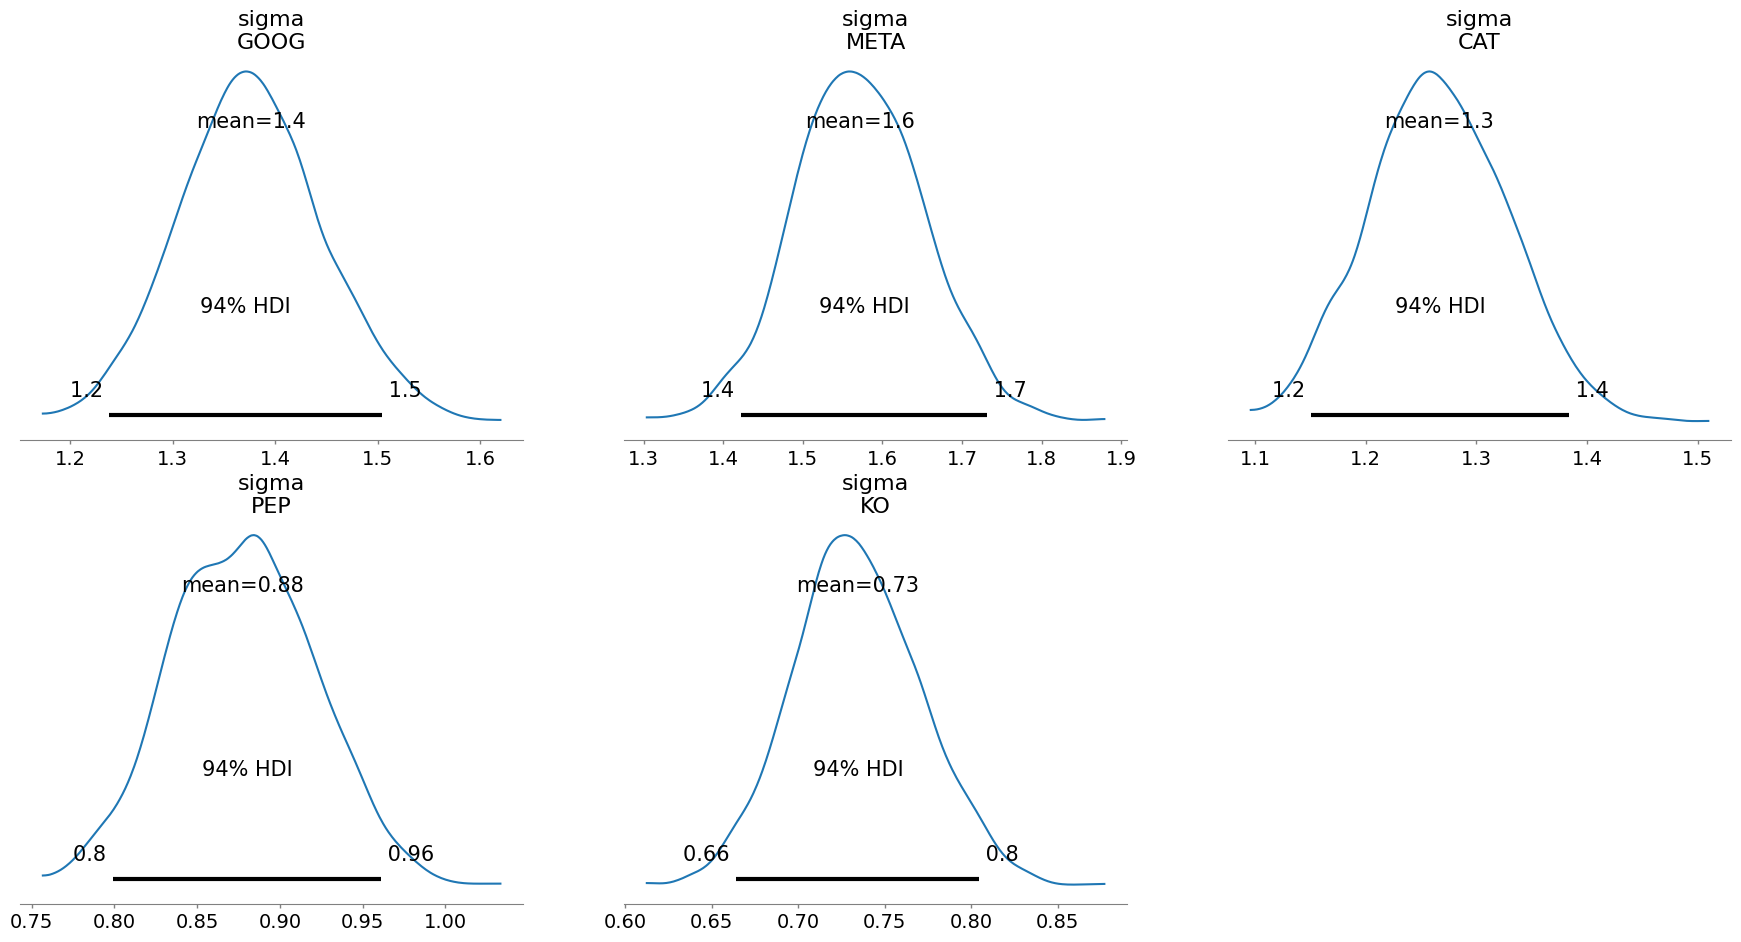

In [238]:
az.plot_posterior(idata_sektors.posterior["sigma"])

array([[<Axes: title={'center': 'mu\nGOOG'}>,
        <Axes: title={'center': 'mu\nMETA'}>,
        <Axes: title={'center': 'mu\nCAT'}>],
       [<Axes: title={'center': 'mu\nPEP'}>,
        <Axes: title={'center': 'mu\nKO'}>, <Axes: >]], dtype=object)

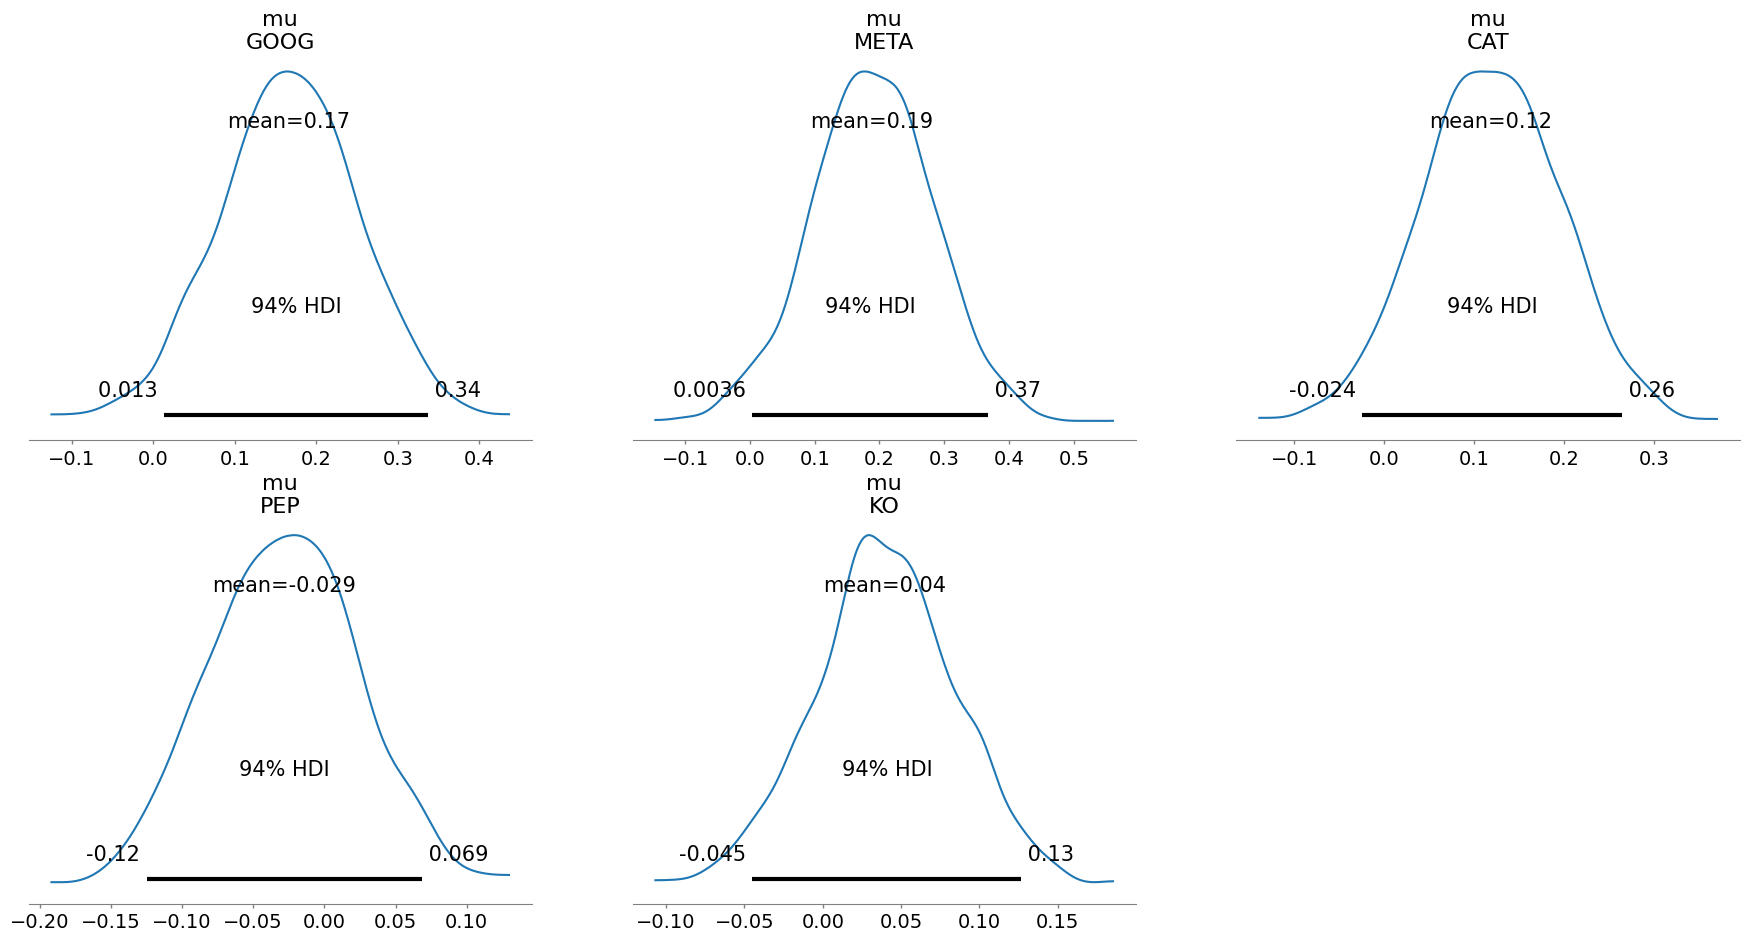

In [239]:
az.plot_posterior(idata_sektors.posterior["mu"])

## Bayesian Regression in Time

A first dynamic model: average daily return as a Student-t variable whose
mean is a linear function of time. This sets up the PPC machinery that
later feeds the price-path simulation.


In [250]:

x = np.arange(len(y_data))  # length of time series (days)
y = y_data.mean(axis=1)     # average daily returns (Y-axis)

# data preparation for PyMC
data = pd.DataFrame({'x': x, 'y': y})

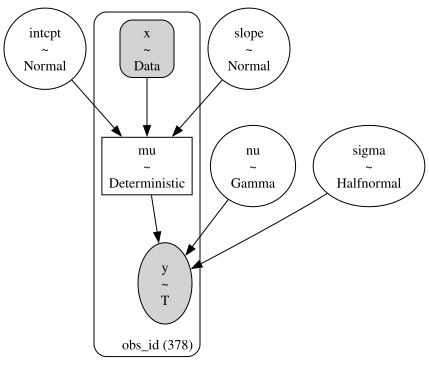

In [251]:
with pm.Model(coords=coords) as t_regression_deterministic:
    #  prior
    intcpt = pm.Normal("intcpt", mu=0, sigma=1)
    slope = pm.Normal("slope", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)
    nu = pm.Gamma("nu", alpha=0.5, beta=1)

    # data
    x_ = pm.Data("x", data["x"], dims="obs_id")

    # we define the regression line as a deterministic variable
    mu = pm.Deterministic("mu", intcpt + slope * x_, dims="obs_id")

    # StudentT model (uses the deterministic variable mu)
    y = pm.StudentT("y", mu=mu, sigma=sigma, nu=nu, observed=data["y"], dims="obs_id")


graph = pm.model_to_graphviz(t_regression_deterministic)
display(graph)

In [252]:

with t_regression_deterministic:
    #step = pm.Metropolis() 
    trace = pm.sample(2000, tune=4000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intcpt, slope, sigma, nu]


/Users/menashelorenzi/Projects/git_repo/bayesian-finance-pymc/.venv/lib/python3.13/site-packages/rich/live.py:256: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 4_000 tune and 2_000 draw iterations (16_000 + 8_000 draws total) took 2 seconds.


array([[<Axes: title={'center': 'intcpt'}>,
        <Axes: title={'center': 'intcpt'}>],
       [<Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'slope'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

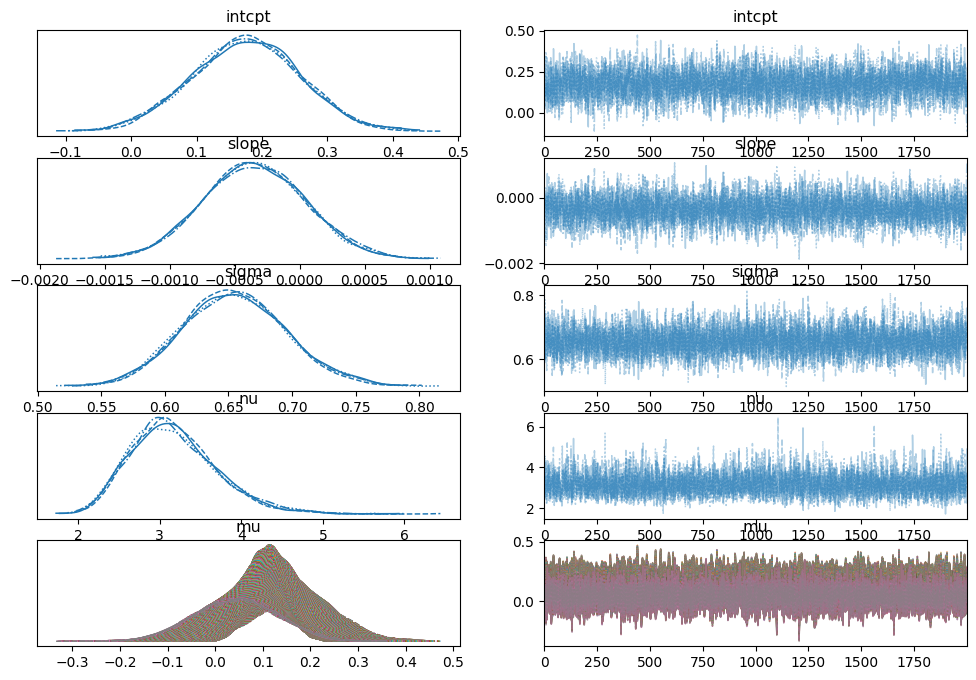

In [253]:
az.plot_trace(trace, figsize=(12, 8))

In [254]:
with t_regression_deterministic:
    ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["mu", "y"] 
    )

Sampling: [y]


/Users/menashelorenzi/Projects/git_repo/bayesian-finance-pymc/.venv/lib/python3.13/site-packages/rich/live.py:256: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [ ]:
plot_regression_with_intervals(trace, ppc, data)

In [260]:
az.summary(trace, var_names=["slope", "intcpt"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
slope,-0.000,0.000,-0.001,0.00,0.000,0.000,4465.0,4752.0,1.0
intcpt,0.176,0.082,0.018,0.34,0.001,0.001,4669.0,5011.0,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

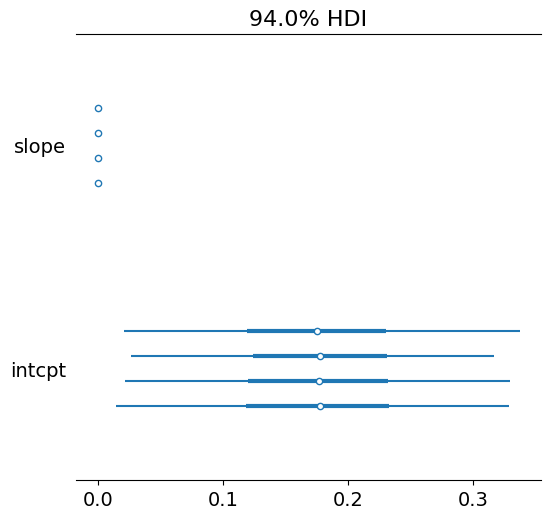

In [261]:
az.plot_forest(trace, var_names=["slope", "intcpt"])


## Hierarchical Bayesian Model

A per-stock intercept and time-slope, each drawn from group-level priors.
We first fit the natural ("centered") parameterization, then rebuild it in
its non-centered form to fix the funnel-shaped posterior geometry that
plain HMC struggles with.


### Model specification

$$
y_{t,i} \sim \mathrm{StudentT}(\nu,\ \mu_{t,i},\ \sigma)
$$
The return of stock \(i\) at time \(t\) follows a Student-t distribution with mean \(\mu_{t,i}\), scale \(\sigma\), and degrees of freedom \(\nu\).
This adds flexibility and lets the model handle outliers.

---

$$
\mu_{t,i} = \alpha_i + \beta_i \cdot t
$$
The mean \(\mu_{t,i}\) of the return is built from a linear-in-time model:
a stock-specific intercept \(\alpha_i\) and a stock-specific time slope \(\beta_i\).

---

$$
\alpha_i \sim \mathcal{N}(\mu_\alpha,\ \sigma_\alpha)
$$
The intercept of stock \(i\) is drawn from a normal distribution shared across all stocks,
with mean \(\mu_\alpha\) and standard deviation \(\sigma_\alpha\).
This is the hierarchical part: each stock is influenced by the group.

---

$$
\beta_i \sim \mathcal{N}(\mu_\beta,\ \sigma_\beta)
$$
The slope of each stock is also drawn from a normal distribution,
with mean \(\mu_\beta\) and standard deviation \(\sigma_\beta\).
This lets us learn a general slope pattern across all stocks.

---

$$
\mu_\alpha \sim \mathcal{N}(\text{intercept\_mu\_alpha},\ \text{slope\_mu\_alpha})
$$
The mean of the intercepts is itself drawn from a normal distribution,
a hyperprior that lets the model also learn the center of the intercepts.

---

$$
\sigma_\alpha \sim \mathrm{HalfCauchy}(0,\ 0.1)
$$
The variance among intercepts is drawn from a Half-Cauchy distribution,
which is suitable for hierarchical models and allows for high variance when needed.

---

$$
\mu_\beta \sim \mathcal{N}(\text{intercept\_mu\_beta},\ \text{slope\_mu\_beta})
$$
The mean of the slopes is drawn from a normal prior with two hyperparameters,
giving flexibility in modeling the group-level slopes.

---

$$
\sigma_\beta \sim \mathrm{HalfCauchy}(0,\ 0.1)
$$
The variance of slopes across stocks is drawn from a Half-Cauchy distribution,
again a flexible prior with heavy tails.

---

$$
\sigma \sim \mathrm{Exponential}(5)
$$
The variance of the residuals (the "noise") of the modeled returns,
constant across stocks and time, drawn from an exponential distribution.

---

$$
\nu \sim \mathrm{Gamma}(2,\ 0.1)
$$
The degrees of freedom of the Student-t distribution, drawn from a Gamma distribution.
This controls how heavy the tails are - a small value yields heavier tails.


### Centered parameterization

In [263]:

# T: number of time points (e.g., days)
# N: number of stocks
T, N = y_data.shape

# Define coordinate names for ArviZ & PyMC to track dimensions
coords = {
    "obs_id": np.arange(T),    # Each time observation
    "stock": TICKERS           # List of stock symbols
}

with pm.Model(coords=coords) as h_model:

    # ---------------------------
    # Input Data
    # ---------------------------

    # x_ is the time variable (e.g., 0, 1, ..., T-1)
    # Declared as mutable so we can later change it for prediction
    x_ = pm.MutableData("x_", np.arange(T), dims="obs_id")

    # ---------------------------
    # Hyperpriors for Group-Level Means and Scales
    # ---------------------------

    # Priors for the group mean and standard deviation of intercepts
    intercept_mu_alpha = pm.Normal("intercept_mu_alpha", 0, sigma=1)
    intercept_mu_beta = pm.Normal("intercept_mu_beta",0, sigma=1)

    # Priors for the group mean and standard deviation of slopes
    slope_mu_alpha = pm.Normal("slope_mu_alpha", 0, sigma=1)
    slope_mu_beta = pm.Normal("slope_mu_beta",0, sigma=1)

    # ---------------------------
    # Hierarchical Priors
    # ---------------------------

    # Mean and std for intercepts across all stocks
    mu_alpha = pm.Normal("mu_alpha", mu=intercept_mu_alpha, sigma=slope_mu_alpha)
    sigma_alpha = pm.HalfCauchy("sigma_alpha", beta=0.1)

    # Mean and std for slopes across all stocks
    mu_beta = pm.Normal("mu_beta", mu=intercept_mu_beta, sigma=slope_mu_beta)
    sigma_beta = pm.HalfCauchy("sigma_beta", beta=0.1)

    # ---------------------------
    # Stock-Specific Parameters (Intercepts and Slopes)
    # ---------------------------

    # One alpha (intercept) and one beta (slope) per stock
    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha, dims="stock")
    beta = pm.Normal("beta", mu=mu_beta, sigma=sigma_beta, dims="stock")

    # ---------------------------
    # Observation Noise and Likelihood
    # ---------------------------

    # Shared noise level for all observations
    sigma = pm.Exponential("sigma", lam=5)

    # Degrees of freedom for the Student-t distribution
    # Gives robustness to outliers
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    # Compute expected value (mean) for each stock at each time point
    # Shape: (T observations, N stocks)
    mu = alpha[None, :] + beta[None, :] * x_[:, None]

    # Observation model: Student-t distribution to account for fat tails
    y_obs = pm.StudentT(
        "y_obs",
        nu=nu,
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims=("obs_id", "stock")
    )

# Optional: visualize the model graph
graph = pm.model_to_graphviz(h_model)
display(graph)


AttributeError: module 'pymc' has no attribute 'MutableData'

In [ ]:
with h_model:
    h_data = pm.sample(
        1000, tune=1000, target_accept=0.8, return_inferencedata=True
    )

SamplingError: Cannot sample from the model, since the model does not contain any free variables.

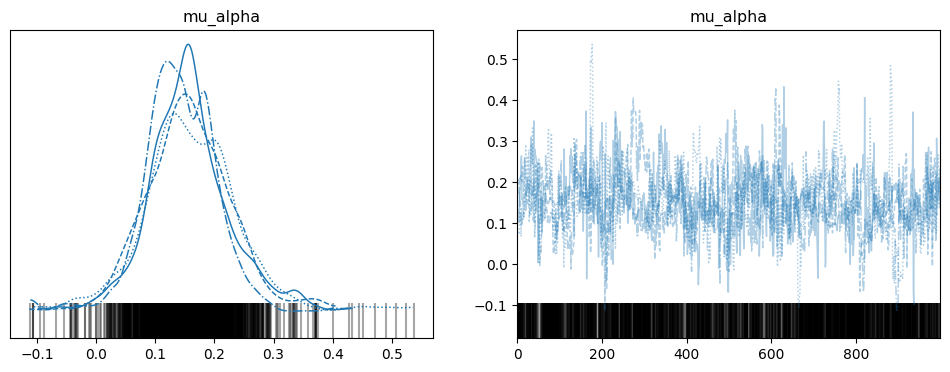

In [ ]:
az.plot_trace(h_data,var_names=["mu_alpha"], figsize=(12, 4))
plt.subplots_adjust(hspace = 0.5)
plt.show()

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'nu'}>,
        <Axes: title={'center': 'nu'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'mu_alpha'}>,
        <Axes: title={'center': 'mu_alpha'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

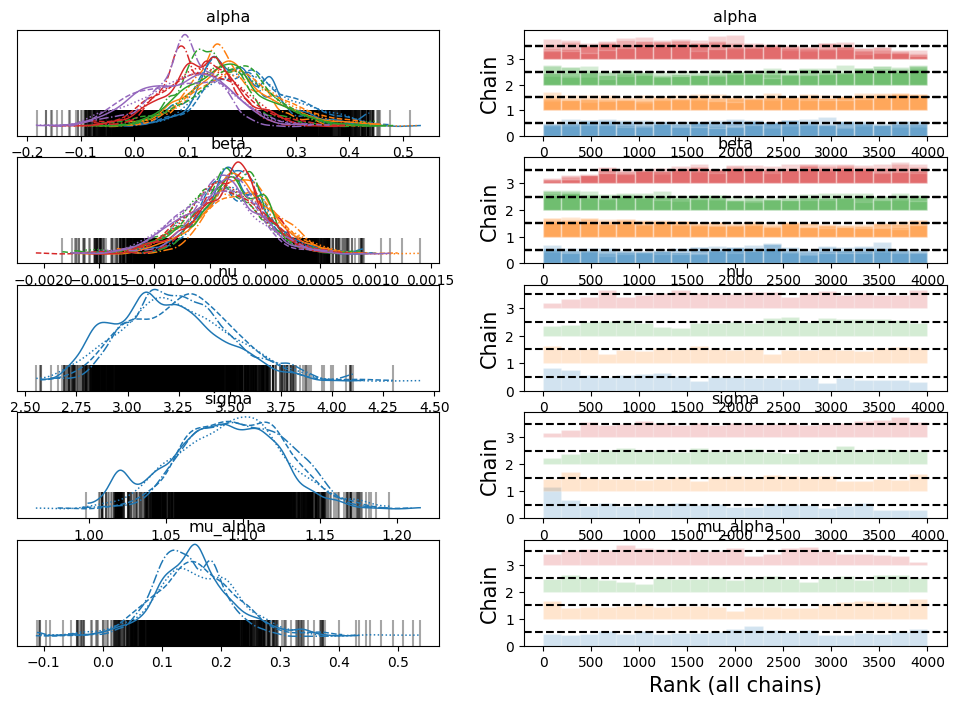

In [ ]:
az.plot_trace(
    h_data,
    kind="rank_bars",
    var_names=["alpha", "beta", "nu", "sigma","mu_alpha"],
    compact=True,           
    figsize=(12, 8),         
    combined=False           
)


### Diagnostics — centered model

**RANK BARS**

We can see that the chains do not sample in a balanced way - for example, chain 3 draws noticeably smaller values than chain 0.

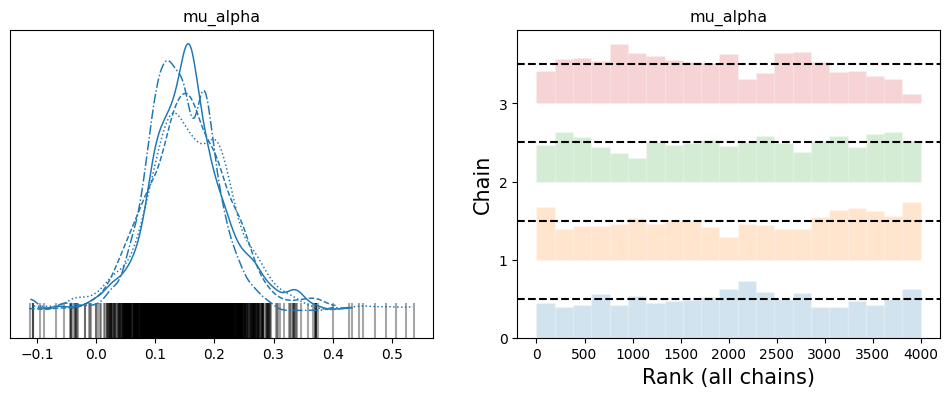

In [ ]:
az.plot_trace(h_data, kind="rank_bars", var_names=["mu_alpha"], figsize = (12, 4));

**AUTOCORR**

Here we can see the autocorrelation between samples - there is high autocorrelation throughout the entire trajectory.

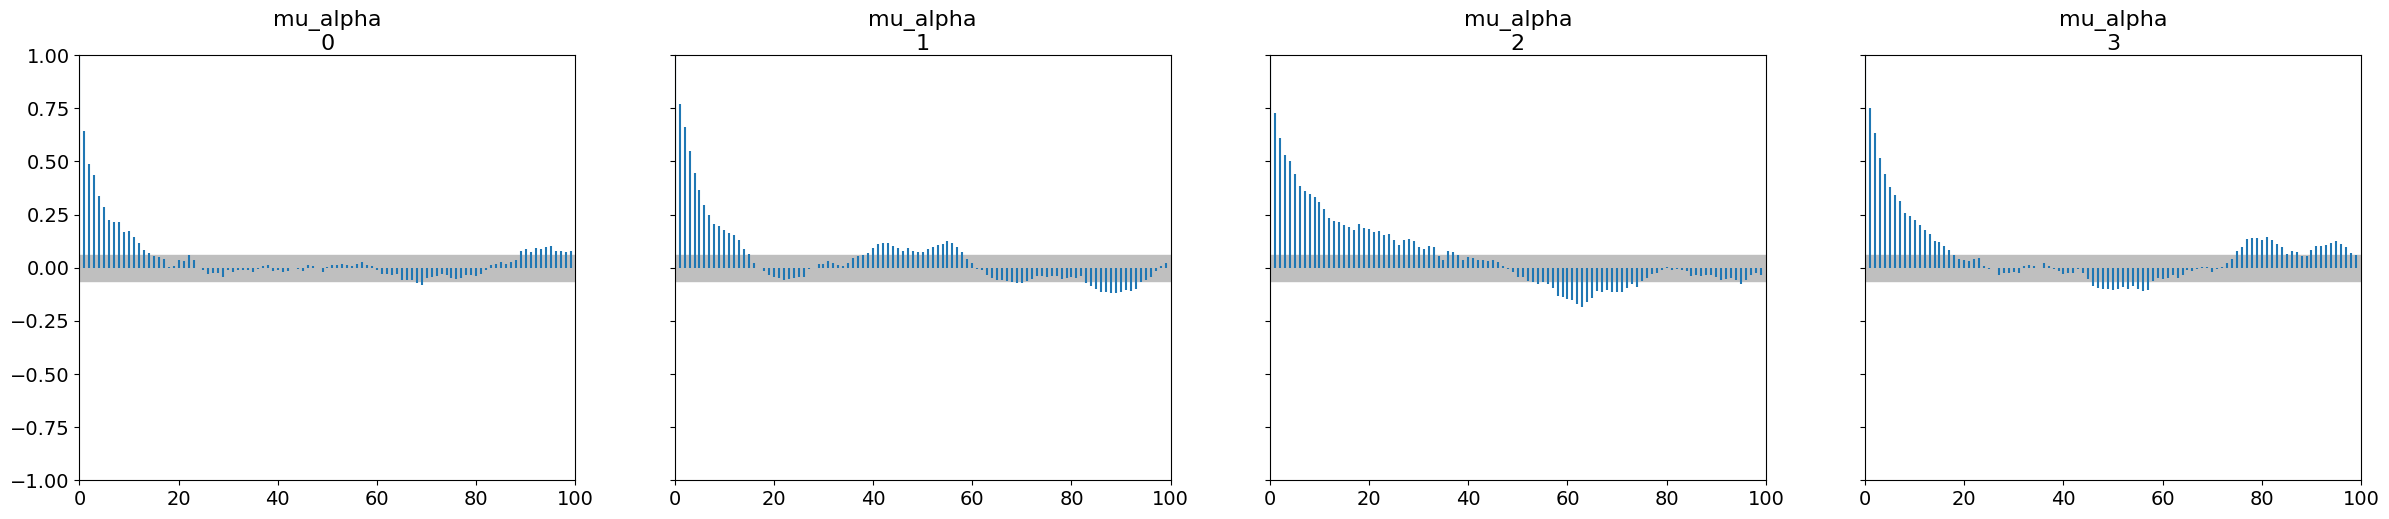

In [ ]:
az.plot_autocorr(h_data, var_names=["mu_alpha"]);

/Users/menashelorenzi/Studies/BSc/Year3/2-AppliedStatistics/.venv/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


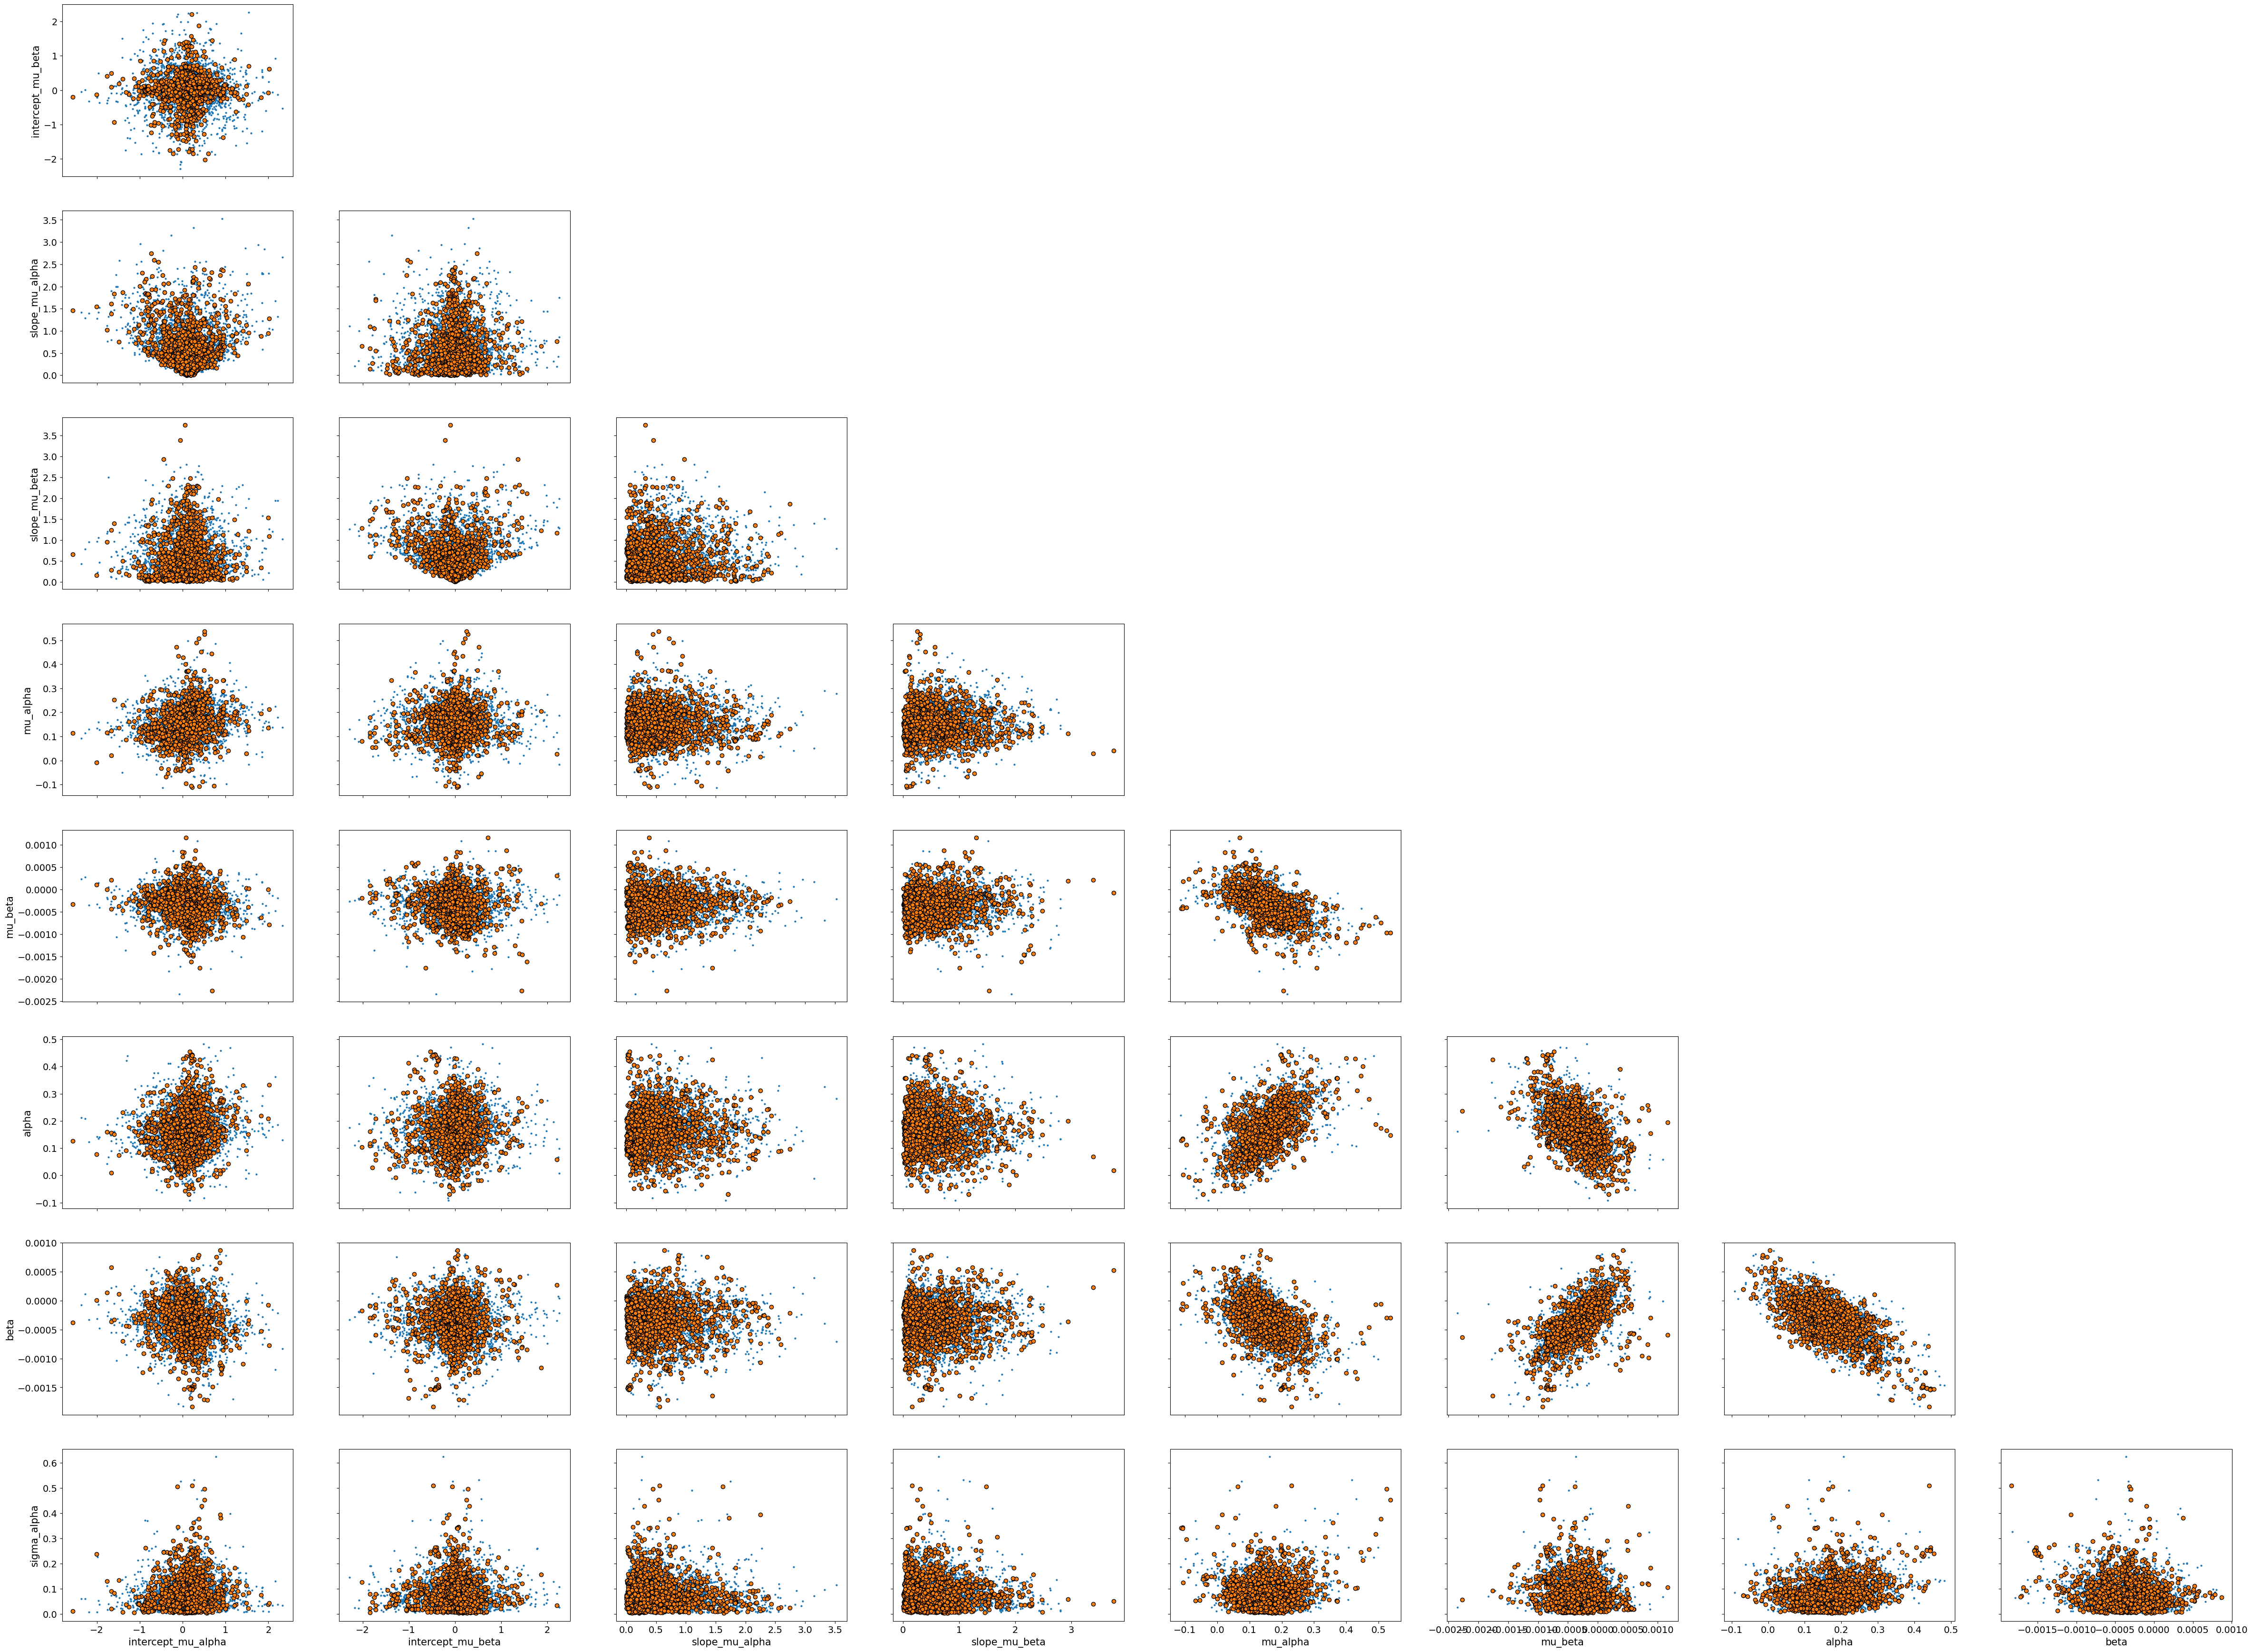

In [ ]:
az.plot_pair(h_data,coords = {"stock": "CAT"}, kind='scatter', divergences=True);

- ESS BULK - HOW MANY INDEPNDET SAMPLES WE HAVE
- ESS TAIL - BAD TAIL ASSASMENT 
- R_HAT - OPTIMAL AT 1

In [ ]:
az.summary(h_data)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept_mu_alpha,0.106,0.504,-0.941,1.032,0.016,0.019,1031.0,960.0,1.01
intercept_mu_beta,-0.014,0.515,-1.121,1.008,0.016,0.021,985.0,1116.0,1.01
slope_mu_alpha,0.633,0.524,0.006,1.635,0.025,0.019,322.0,378.0,1.02
slope_mu_beta,0.623,0.502,0.010,1.540,0.024,0.015,364.0,705.0,1.00
mu_alpha,0.154,0.071,0.018,0.282,0.004,0.003,289.0,493.0,1.01
mu_beta,-0.000,0.000,-0.001,0.000,0.000,0.000,220.0,416.0,1.02
alpha[GOOG],0.205,0.083,0.049,0.369,0.005,0.003,266.0,457.0,1.02
alpha[META],0.186,0.082,0.040,0.349,0.005,0.003,313.0,492.0,1.02
alpha[CAT],0.170,0.079,0.026,0.328,0.005,0.003,296.0,461.0,1.02
alpha[KO],0.124,0.073,-0.009,0.261,0.004,0.003,363.0,561.0,1.01


<Axes: title={'center': 'mu_alpha'}, xlabel='Quantile', ylabel='ESS for small intervals'>

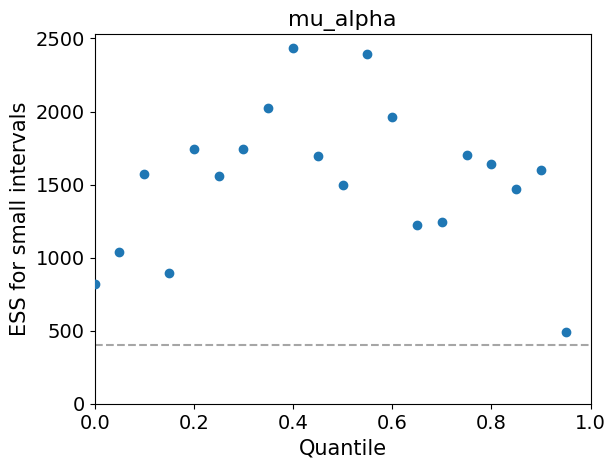

In [ ]:
az.plot_ess(h_data,var_names=["mu_alpha"],coords = {"stock": "CAT"},)

array([[<Axes: title={'center': 'intercept_mu_alpha'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'intercept_mu_beta'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'slope_mu_alpha'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'slope_mu_beta'}, xlabel='Total number of draws', ylabel='ESS'>],
       [<Axes: title={'center': 'mu_alpha'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'mu_beta'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'alpha\nGOOG'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'alpha\nMETA'}, xlabel='Total number of draws', ylabel='ESS'>],
       [<Axes: title={'center': 'alpha\nCAT'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'alpha\nKO'}, xlabel='Total number of draws', ylabel='ESS'>,
        <Axes: title={'center': 'alpha\n

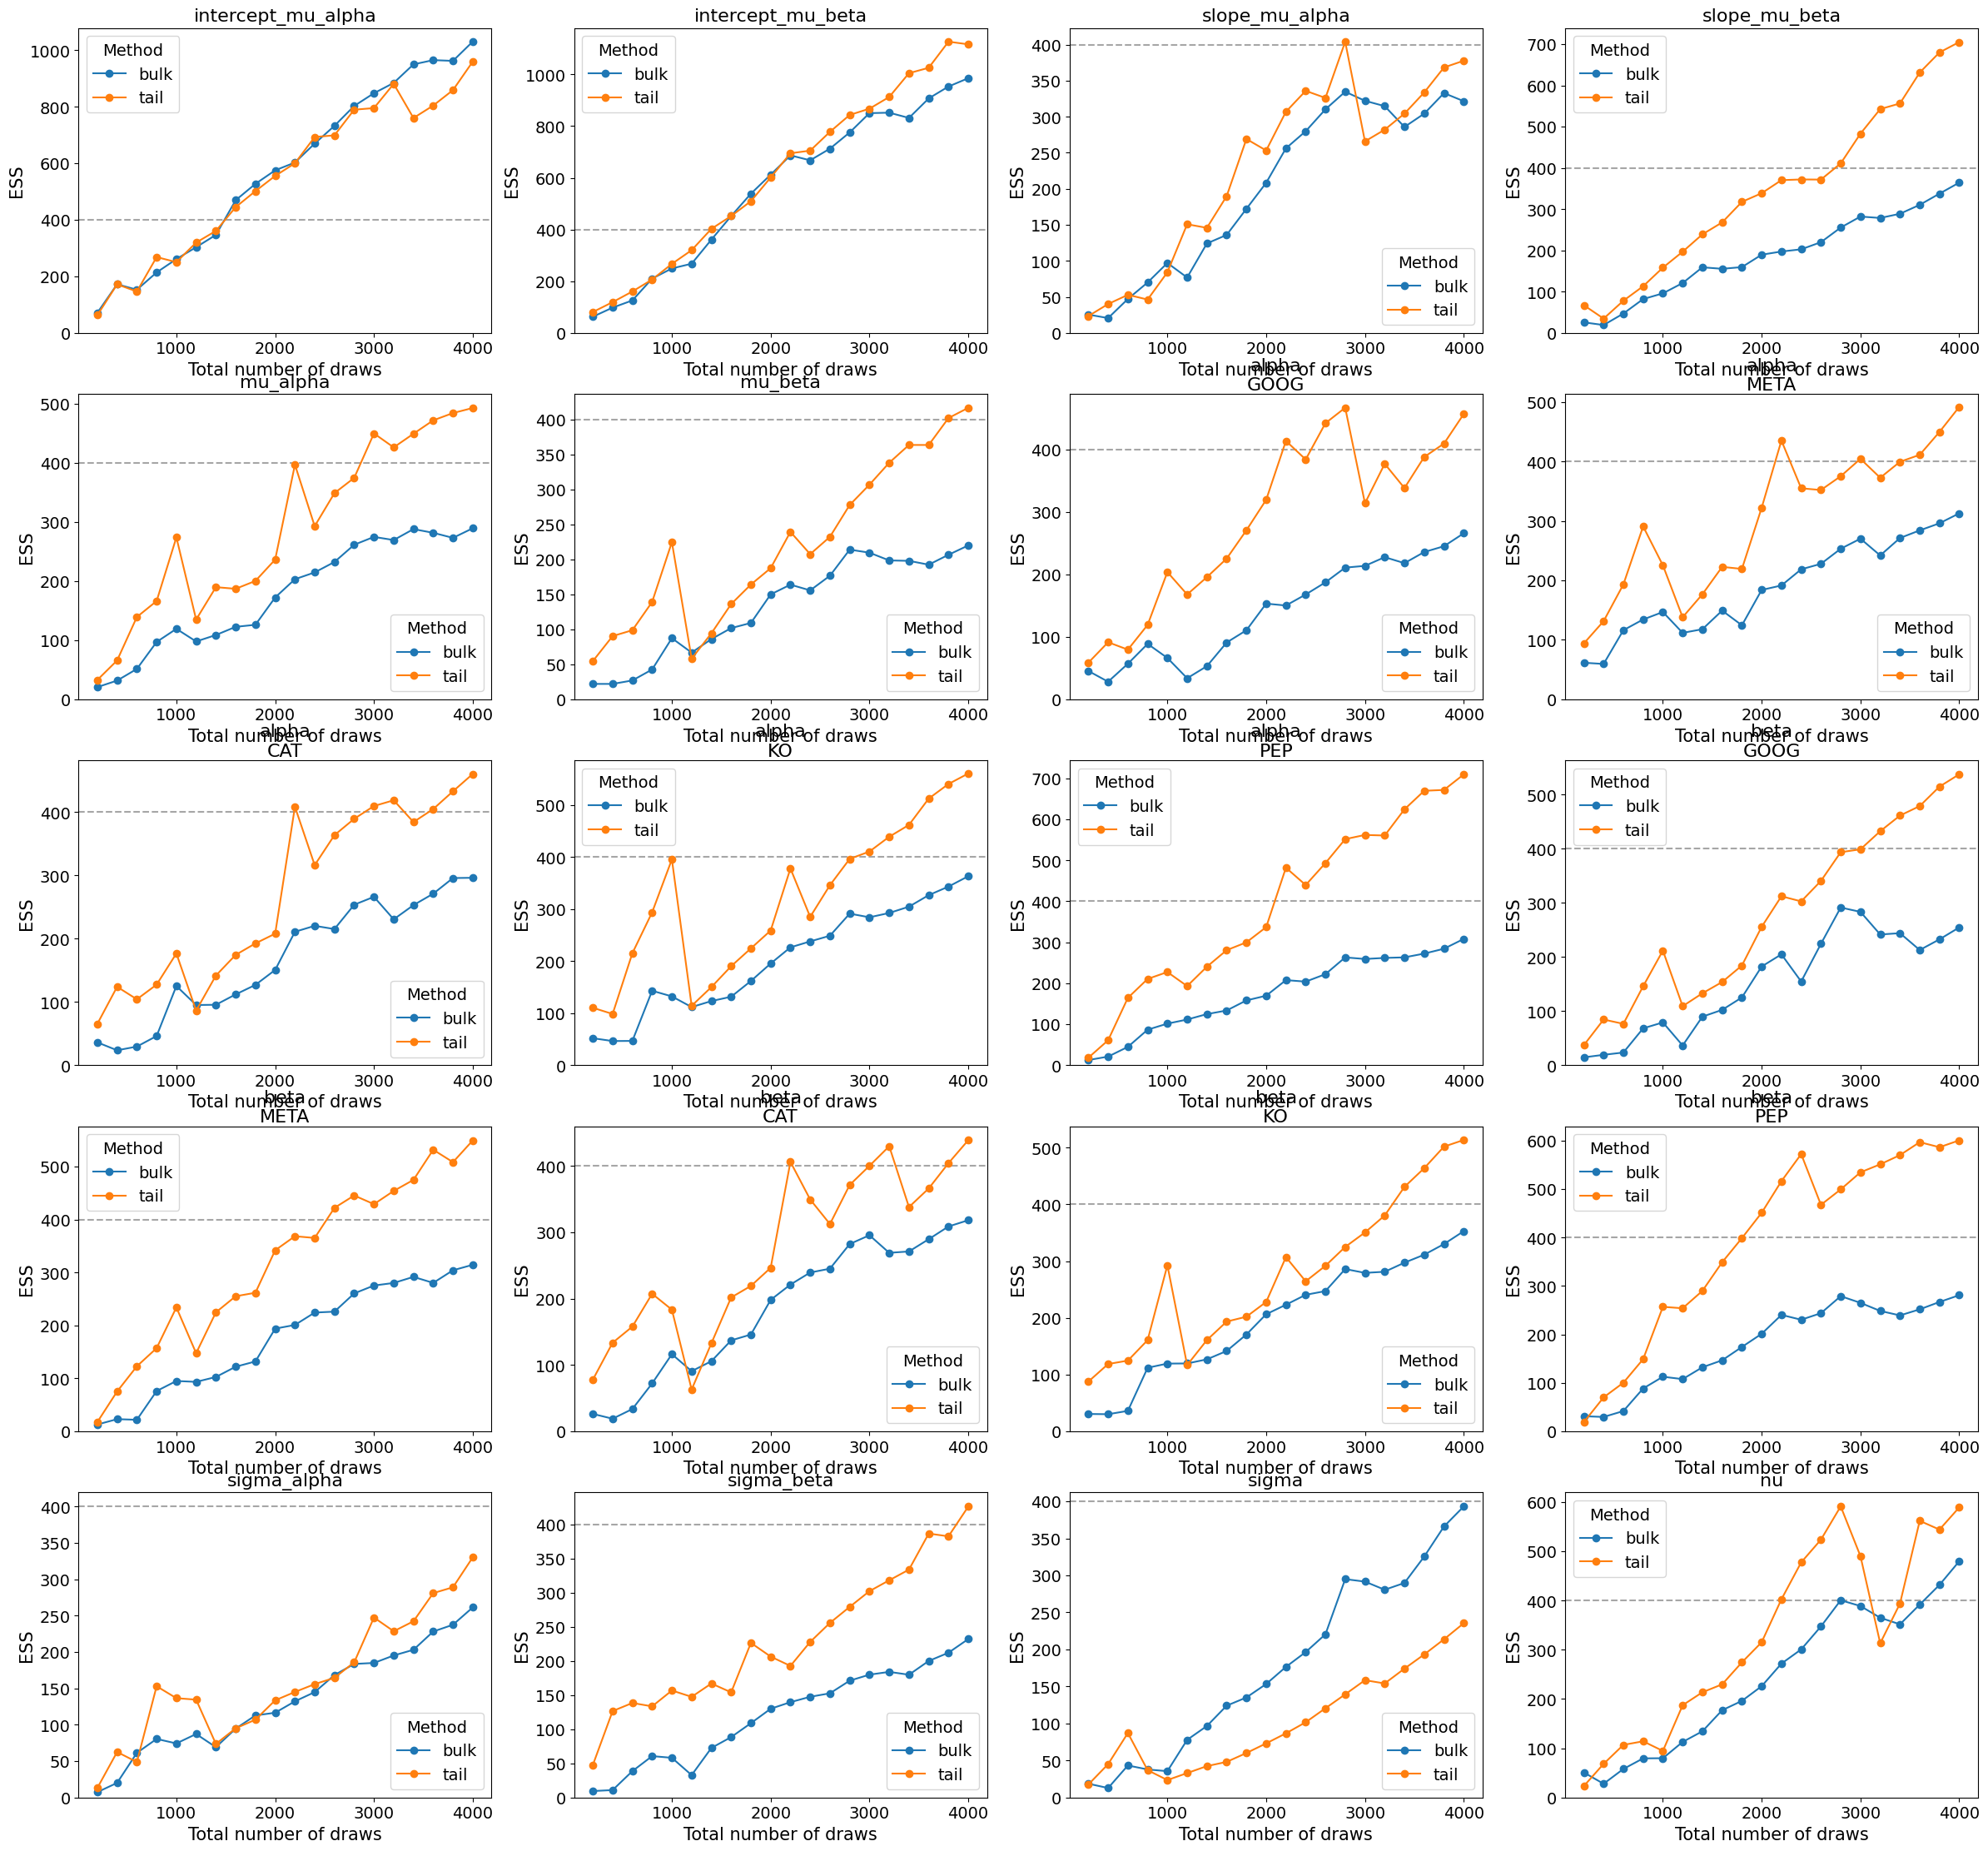

In [ ]:
az.plot_ess(h_data,kind='evolution')

### Non-centered parameterization

The diagnostics above show divergences and high autocorrelation - signs of
the classic *funnel* geometry that the centered hierarchical model induces
when the group-level scale `sigma_alpha`/`sigma_beta` is small. Rewriting
`alpha` and `beta` as a deterministic function of an offset variable
(`alpha = mu_alpha + sigma_alpha * alpha_offset`, etc.) lets the sampler
work on a unit-scale Gaussian and recovers good mixing.


/Users/menashelorenzi/Studies/BSc/Year3/2-AppliedStatistics/.venv/lib/python3.13/site-packages/pymc/data.py:265: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(


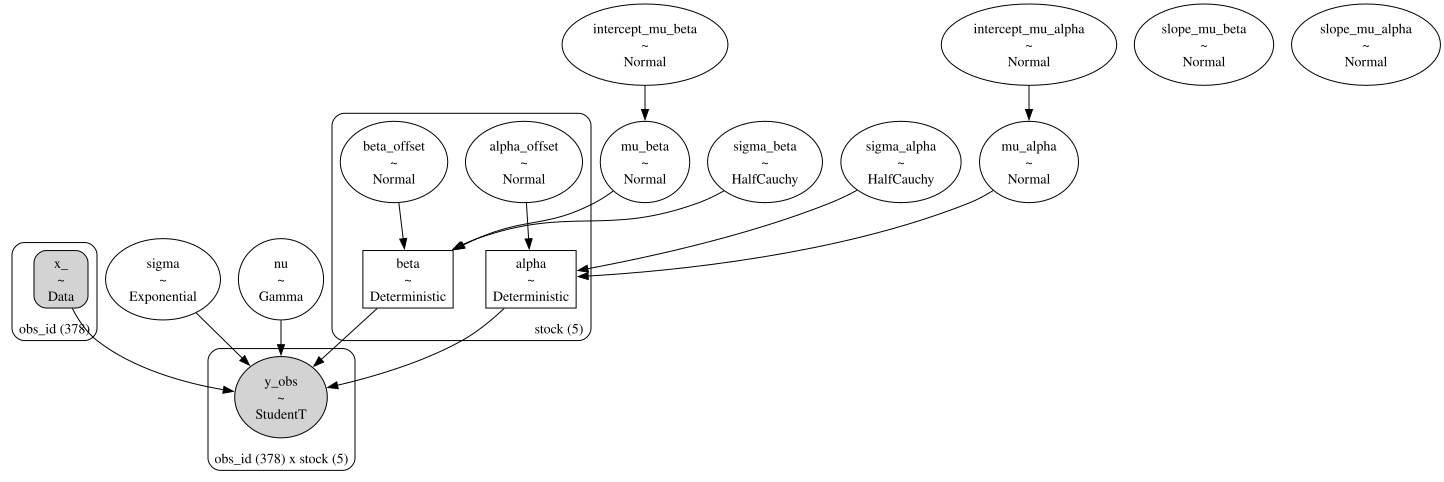

In [ ]:
with pm.Model(coords=coords) as h_model:

    # ---------------------------
    # Input Data
    # ---------------------------

    x_ = pm.MutableData("x_", np.arange(T), dims="obs_id")

    # ---------------------------
    # Hyperpriors for Group-Level Means and Scales
    # ---------------------------

    intercept_mu_alpha = pm.Normal("intercept_mu_alpha", 0, sigma=1)
    intercept_mu_beta  = pm.Normal("intercept_mu_beta", 0, sigma=1)

    slope_mu_alpha = pm.Normal("slope_mu_alpha", 0, sigma=1)
    slope_mu_beta  = pm.Normal("slope_mu_beta", 0, sigma=1)

    mu_alpha  = pm.Normal("mu_alpha", mu=intercept_mu_alpha, sigma=1)
    sigma_alpha = pm.HalfCauchy("sigma_alpha", beta=0.1)

    mu_beta  = pm.Normal("mu_beta", mu=intercept_mu_beta, sigma=1)
    sigma_beta = pm.HalfCauchy("sigma_beta", beta=0.1)

    # ---------------------------
    # Non-Centered Stock-Level Parameters
    # ---------------------------

    alpha_offset = pm.Normal("alpha_offset", mu=0, sigma=1, dims="stock")
    beta_offset  = pm.Normal("beta_offset", mu=0, sigma=1, dims="stock")

    alpha = pm.Deterministic("alpha", mu_alpha + sigma_alpha * alpha_offset, dims="stock")
    beta  = pm.Deterministic("beta", mu_beta + sigma_beta * beta_offset, dims="stock")

    # ---------------------------
    # Observation Noise and Likelihood
    # ---------------------------

    sigma = pm.Exponential("sigma", lam=5)
    nu    = pm.Gamma("nu", alpha=2, beta=0.1)

    # Linear model
    mu = alpha[None, :] + beta[None, :] * x_[:, None]

    y_obs = pm.StudentT(
        "y_obs",
        nu=nu,
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims=("obs_id", "stock")
    )

graph = pm.model_to_graphviz(h_model)
display(graph)

In [ ]:
with h_model:
    h_data = pm.sample(
        1000, tune=1000, target_accept=0.8, return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_mu_alpha, intercept_mu_beta, slope_mu_alpha, slope_mu_beta, mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha_offset, beta_offset, sigma, nu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


/Users/menashelorenzi/Studies/BSc/Year3/2-AppliedStatistics/.venv/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


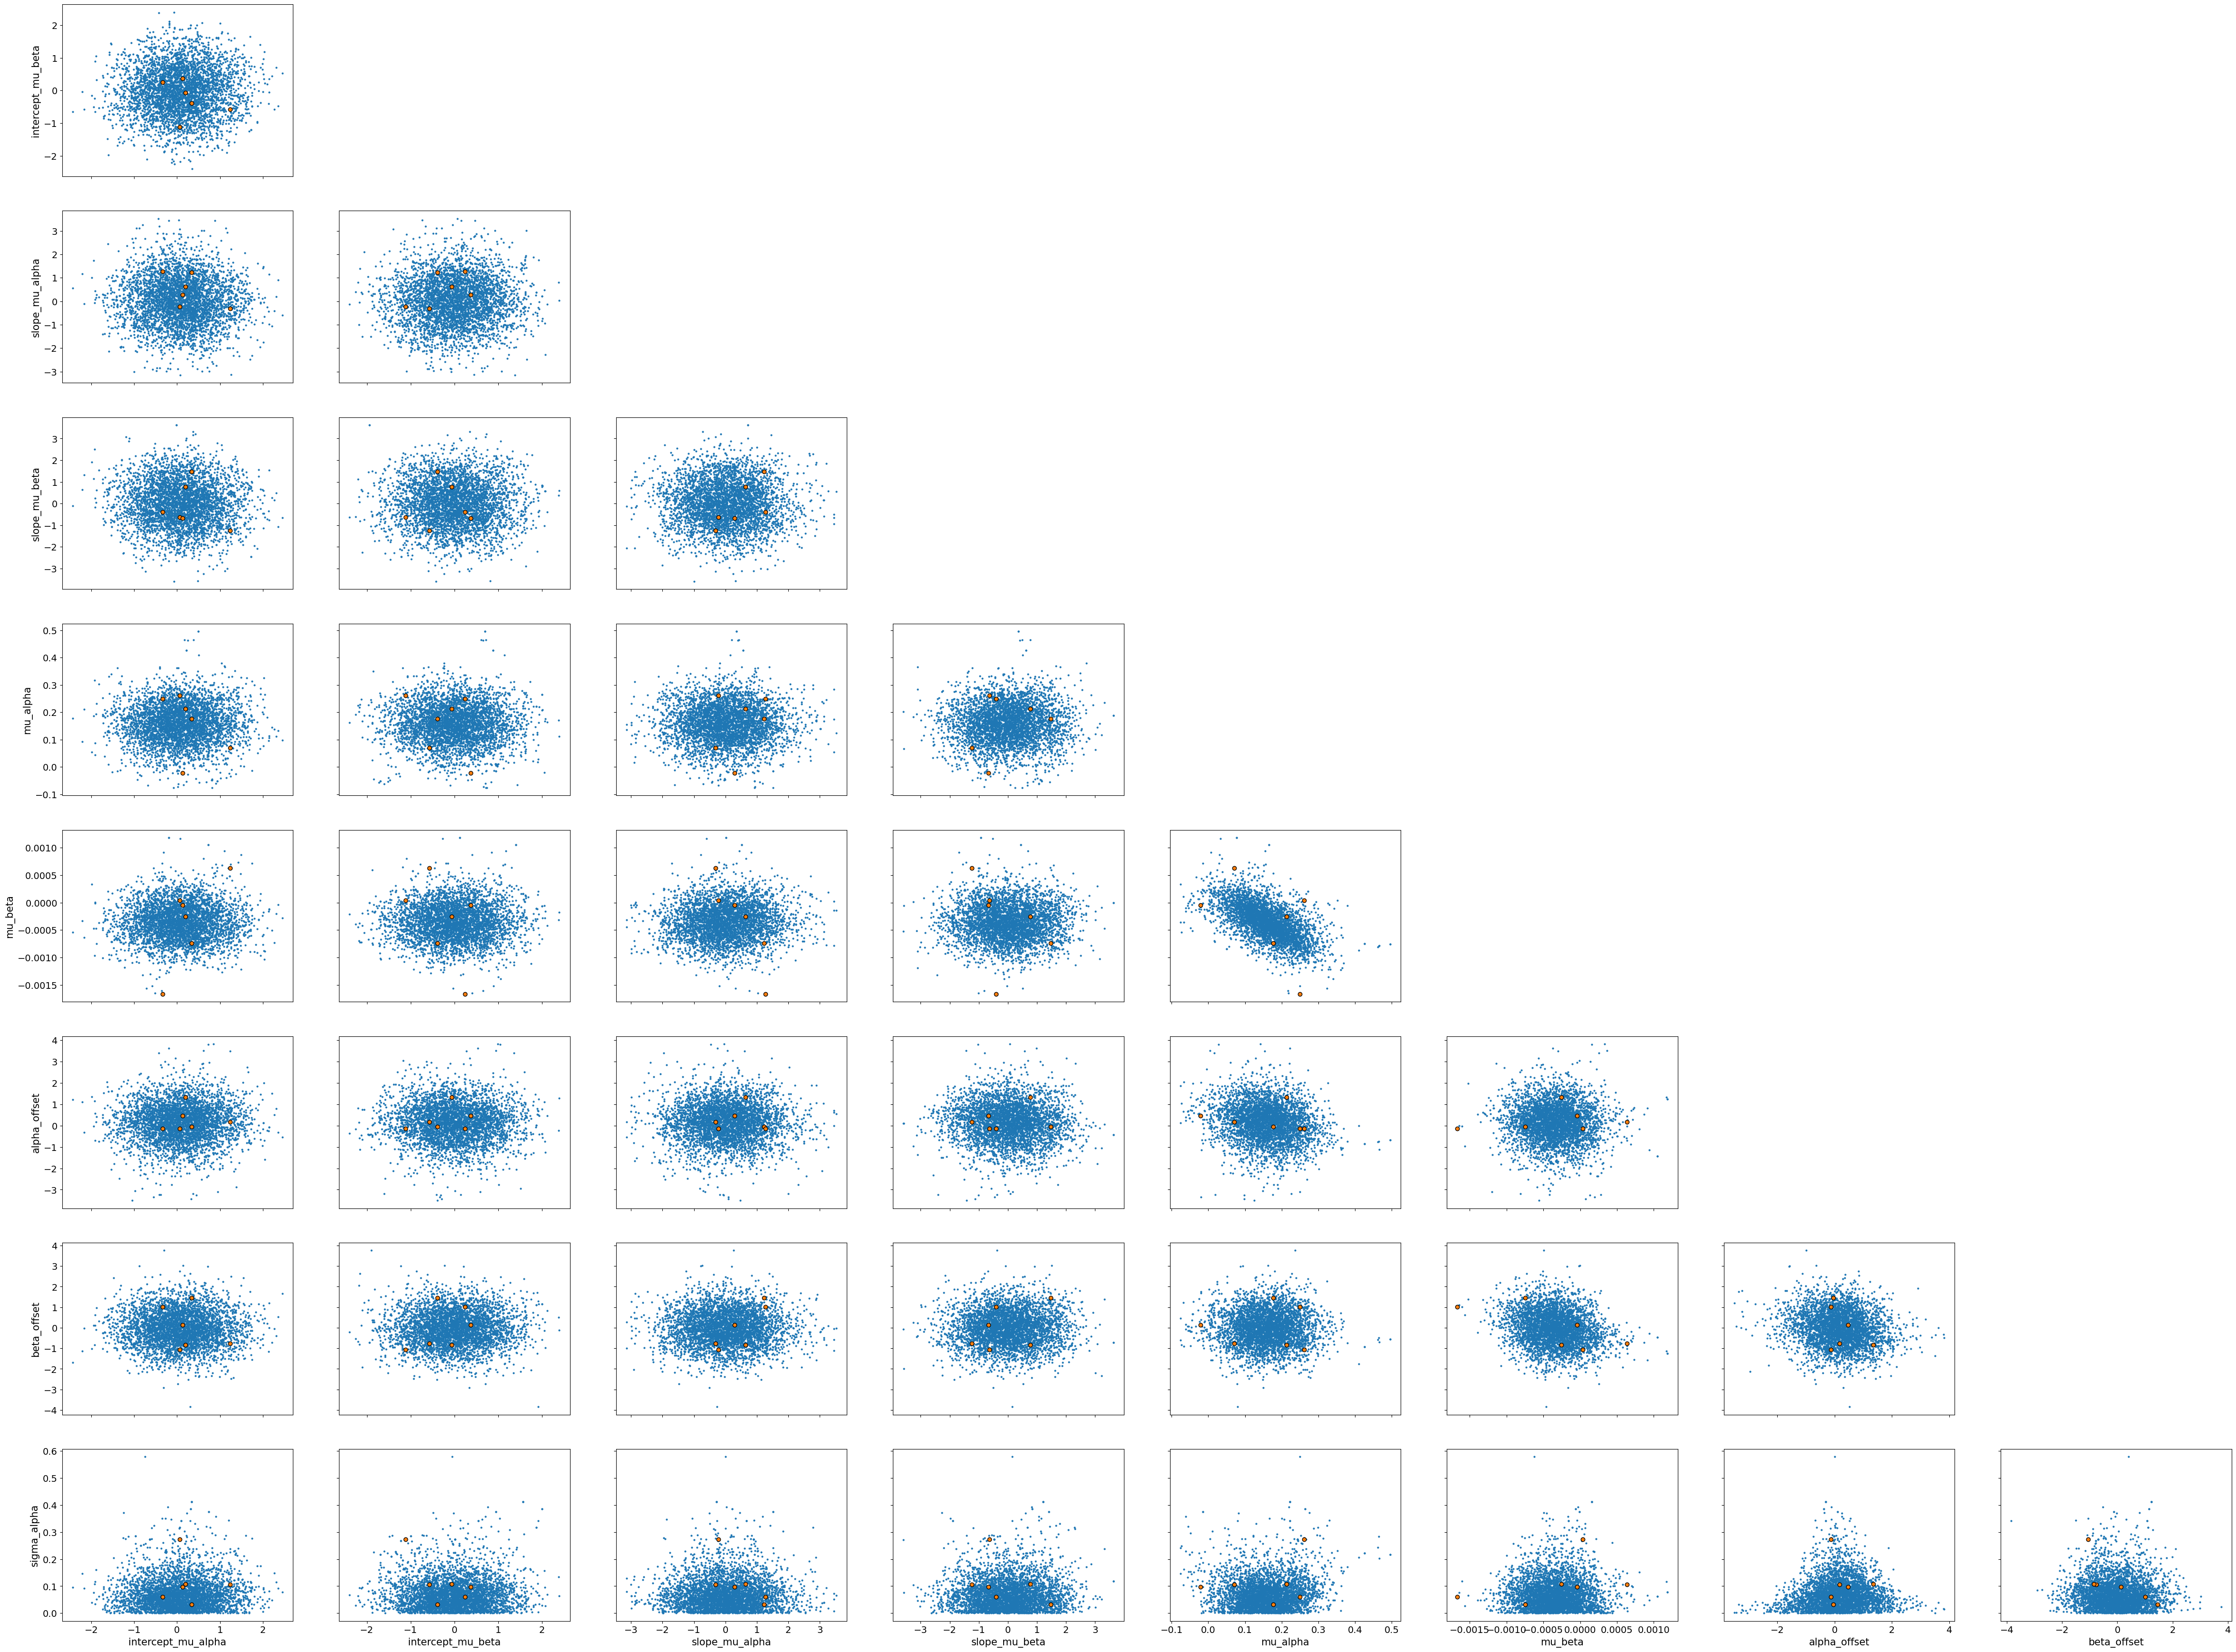

In [ ]:
az.plot_pair(h_data,coords = {"stock": "CAT"}, kind='scatter', divergences=True);

## Posterior Predictive: Price Simulation

We use the posterior predictive of the time-regression model to extract a
per-day variance/volatility estimate, draw a representative return path,
and reconstruct an expected price trajectory with a 2σ band.


In [ ]:
random_samples, variances_per_y, volatility_per_y, results_df = compute_predicted_volatility(ppc, num_days)
print(f"Sampled {len(random_samples)} values. Shape of variance array: {variances_per_y.shape}")
print(results_df.head())


In [ ]:
P0 = prices_clean.mean(axis=1).iloc[0]  # average price on the first day
print(f"Initial price P0: {P0}")

price_paths, upper_band, lower_band = simulate_price_paths(P0, random_samples, volatility_per_y)


In [ ]:
real_prices = prices_clean.mean(axis=1).values
plot_simulated_paths(price_paths, lower_band, upper_band, real_prices)
